# Preliminary Data Overview for `mixscape_hvg_filter.h5ad`

This notebook is a lightweight walkthrough of the dataset for our project team. The goal is to understand what is in the file, what metadata we can use, and how the dataset connects to our planned causal analysis of perturbation effects.

This is intentionally a **preliminary notebook**. It does not run the full analysis yet. Instead, it helps us:

- load the dataset and inspect its structure
- review cell-level and gene-level metadata
- explore perturbation and Mixscape labels
- visualize the existing UMAP embedding
- identify fields that will likely be useful as outcomes, treatments, and covariates later


## Project Context

Our draft project focuses on estimating causal effects of genetic perturbations in single-cell Perturb-seq data. Rather than trying to recover a full gene regulatory network, we plan to study a simpler causal estimand: the effect of a selected perturbation on a low-dimensional outcome such as a gene program or pathway score.

That means the dataset needs to provide three basic ingredients:

- a treatment indicator or perturbation assignment
- an outcome we can define from expression data
- covariates that capture cell state and technical variation

This notebook helps us locate those ingredients in the `.h5ad` file.

In [2]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import tarfile
from urllib.request import urlretrieve

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except ImportError:
    sns = None

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)


## Downloading the Data

If the dataset is not already present locally, the next cell can download it from PerturBase and extract it into a `data/` directory.

Source archive:

- `http://www.perturbase.cn/static/UPR_Perturb_seq/UPR_Perturb_seq.filter.tar.gz`

This step is optional if you already have `mixscape_hvg_filter.h5ad` in the project folder.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from pathlib import Path
from urllib.request import urlretrieve
import tarfile

DATA_URL = 'http://www.perturbase.cn/static/UPR_Perturb_seq/UPR_Perturb_seq.filter.tar.gz'
EXTRACT_DIR = Path('/content/drive/MyDrive/MyProjectData')
ARCHIVE_PATH = EXTRACT_DIR / 'UPR_Perturb_seq.filter.tar.gz'
TARGET_NAME = 'mixscape_hvg_filter.h5ad'

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

candidate_paths = [
    Path(TARGET_NAME),
    EXTRACT_DIR / TARGET_NAME,
]
candidate_paths.extend(EXTRACT_DIR.rglob(TARGET_NAME))

if any(path.exists() for path in candidate_paths):
    print('Dataset already present locally. Skipping download.')
else:
    if not ARCHIVE_PATH.exists():
        print(f'Downloading archive from {DATA_URL} ...')
        urlretrieve(DATA_URL, ARCHIVE_PATH)
    else:
        print(f'Using existing archive: {ARCHIVE_PATH}')

    print(f'Extracting {ARCHIVE_PATH} into {EXTRACT_DIR} ...')
    with tarfile.open(ARCHIVE_PATH, 'r:gz') as tar:
        tar.extractall(EXTRACT_DIR)

    print('Extraction finished.')

Dataset already present locally. Skipping download.


In [8]:
from pathlib import Path
import anndata as ad

data_path = Path('/content/drive/MyDrive/MyProjectData/mixscape_hvg_filter.h5ad')

adata = ad.read_h5ad(data_path)
print(adata)

AnnData object with n_obs × n_vars = 43550 × 2000
    obs: 'gene', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'mixscape_class_p_ko', 'mixscape_class', 'mixscape_class_global', 'pertclass'
    var: 'ENSEMBL', 'ENTREZID', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden', 'log1p', 'mixscape', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'X_pert', 'normal_counts'
    obsp: 'connectivities', 'distances'


In [9]:
df = adata.to_df()
df

Gene_symbol,MIR1302-10,SAMD11,HES4,TNFRSF18,TNFRSF4,TAS1R3,RP11-181G12.2,AL590822.2,RP11-181G12.4,RP11-46F15.2,SMIM1,ESPN,TNFRSF25,TAS1R1,RP11-242F24.1,TNFRSF9,GPR157,SPSB1,CASZ1,RP1-69M21.2,C1orf158,RP3-467K16.2,EFHD2,CELA2A,ACTL8,IFFO2,PLA2G2C,ID3,FUCA1,C1orf63,PAQR7,STMN1,SH3BGRL3,CD52,SYTL1,CD164L2,SESN2,SNHG12,RAB42,LAPTM5,FABP3,TINAGL1,RP11-277A4.4,RP1-27O5.3,RP11-114B7.6,TMEM54,SFPQ,CLSPN,CSF3R,CDCA8,...,RP4-633O19__A.1,LL22NC01-81G9.3,SSTR3,RAC2,CYTH4,LGALS2,LGALS1,MAFF,PDGFB,RP1-85F18.5,RP4-756G23.5,CSDC2,MEI1,NFAM1,ARFGAP3,BIK,GTSE1,CTA-29F11.1,CRELD2,PIM3,RP3-402G11.27,CTA-384D8.35,CTA-384D8.34,KLHDC7B,CTA-384D8.33,SAMSN1,AP001171.1,APP,AP001596.6,KRTAP19-1,TIAM1,C21orf49,AP000692.10,AP000695.4,CLDN14,ETS2,BACE2,LINC00479,ZNF295-AS1,C21orf128,TFF3,AP001046.5,AP001053.11,ICOSLG,ITGB2,COL6A1,MT-ND1,MT-ND2,MT-ATP6,MT-ND5
Cell_barcodes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CTCATTGAGAAGGC-6,0.0,0.0,-0.193769,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,-0.355879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.247189,0.000000,-0.190549,0.0,0.0,-0.195300,0.239855,0.283501,0.000000,-0.767393,0.463227,-0.436983,-0.018057,0.0,-0.247302,0.425352,0.000000,0.616093,-0.016719,0.0,0.0,0.0,0.0,0.144129,-0.018533,0.057238,-0.013962,-0.552958,...,0.0,0.0,0.0,-0.011388,0.0,0.0,-0.118620,-0.017413,0.0,0.0,0.0,0.0,0.000000,0.0,0.360924,0.000000,0.083020,-0.279624,0.303346,-0.378813,0.0,0.0,0.0,0.000000,0.0,-0.557076,-0.146101,0.0,0.0,0.0,0.0,0.0,-0.048022,0.000000,0.0,0.357810,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.018873,0.0,0.358048,0.400132,-0.018314,0.175453
CGGCACGATGACCA-6,0.0,0.0,0.224644,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.197364,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.096924,0.000000,0.000000,0.0,0.0,-0.073322,-0.246804,-0.377945,0.000000,0.034258,-0.118209,-0.140217,0.000000,0.0,-0.503518,-0.098304,-0.020436,-0.597238,0.000000,0.0,0.0,0.0,0.0,-0.134366,0.285998,-0.023533,-0.041711,0.318011,...,0.0,0.0,0.0,-0.283471,0.0,0.0,-0.604168,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,1.119483,0.000000,0.182492,-0.211405,-0.105934,-0.350689,0.0,0.0,0.0,0.000000,0.0,0.964835,0.433842,0.0,0.0,0.0,0.0,0.0,-0.027253,0.000000,0.0,-0.189810,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.239548,-0.013457,0.175203,0.126030
AACCTTACTGACCA-7,0.0,0.0,-0.293438,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,-0.029709,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.223413,0.000000,0.000000,0.0,0.0,-0.027535,-0.357927,1.519233,0.000000,0.114336,-0.850383,-0.823612,-0.060158,0.0,-0.224307,-0.125344,0.000000,0.831552,-0.026035,0.0,0.0,0.0,0.0,-0.239946,0.590246,-0.528246,0.000000,-0.436613,...,0.0,0.0,0.0,-0.788506,0.0,0.0,-0.473226,-0.039798,0.0,0.0,0.0,0.0,0.000000,0.0,-0.197055,0.000000,-0.360780,-0.559127,-0.482097,-0.302789,0.0,0.0,0.0,-0.019735,0.0,0.232667,0.761695,0.0,0.0,0.0,0.0,0.0,-0.029254,-0.027535,0.0,-0.105819,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.061748,0.0,-1.593203,-1.015736,-0.530311,-0.017070
GAACGGGAAGTCAC-3,0.0,0.0,0.682660,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,-0.053884,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.131971,0.000000,-0.038594,0.0,0.0,0.000000,0.367556,-0.508512,0.000000,-0.618632,-0.168438,-0.011276,0.000000,0.0,0.342781,-0.032971,0.000000,0.378281,0.000000,0.0,0.0,0.0,0.0,-0.279066,0.369384,-0.062400,0.000000,0.000000,...,0.0,0.0,0.0,0.403566,0.0,0.0,-0.312125,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,-0.197402,-0.031212,-0.031212,-0.216162,-0.420682,-0.347252,0.0,0.0,0.0,0.000000,0.0,0.307876,0.328262,0.0,0.0,0.0,0.0,0.0,-0.022582,0.000000,0.0,-0.074508,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,-0.007768,-0.300343,-0.512433,0.005712
CAACGAACATCGGT-9,0.0,0.0,0.272235,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,-0.252386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.273637,-0.023987,-0.083317,0.0,0.0,-0.108584,-0.274457,0.022524,-0.018825,-0.116535,0.789633,0.135973,-0.037658,0.0,0.578075,0.000000,0.000000,0.316987,-0.027801,0.0,0.0,0.0,0.0,-0.179457,-0.185600,0.217329,-0.140912,-0.187022,...,0.0,0.0,0

## First Look

AnnData stores a main expression matrix `X` together with metadata and analysis results:

- `obs`: cell-level metadata
- `var`: gene-level metadata
- `layers`: alternate matrices
- `obsm`: low-dimensional embeddings such as PCA and UMAP
- `obsp`: pairwise graphs such as neighbor connectivities
- `uns`: unstructured analysis metadata

Since the file is already processed, it should give us a good starting point for downstream exploratory and causal work.

In [10]:
summary = {
    'n_cells': adata.n_obs,
    'n_genes': adata.n_vars,
    'obs_columns': list(adata.obs.columns),
    'var_columns': list(adata.var.columns),
    'layers': list(adata.layers.keys()),
    'obsm': list(adata.obsm.keys()),
    'obsp': list(adata.obsp.keys()),
    'uns': list(adata.uns.keys()),
    'varm': list(adata.varm.keys()),
}

for key, value in summary.items():
    print(f'\n{key}:')
    print(value)



n_cells:
43550

n_genes:
2000

obs_columns:
['gene', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'mixscape_class_p_ko', 'mixscape_class', 'mixscape_class_global', 'pertclass']

var_columns:
['ENSEMBL', 'ENTREZID', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm']

layers:
['X_pert', 'normal_counts']

obsm:
['X_pca', 'X_umap']

obsp:
['connectivities', 'distances']

uns:
['hvg', 'leiden', 'log1p', 'mixscape', 'neighbors', 'pca', 'umap']

varm:
['PCs']


In [11]:
adata.obs.head()

,gene,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,mixscape_class_p_ko,mixscape_class,mixscape_class_global,pertclass
Cell_barcodes,,,,,,,,,,,
CTCATTGAGAAGGC-6,NEDD8,3820,3820,16201.0,979.0,6.042837,0,0.999475,NEDD8 KO,KO,strong
CGGCACGATGACCA-6,DAD1,3853,3853,16371.0,835.0,5.100483,2,0.854574,DAD1 KO,KO,strong
AACCTTACTGACCA-7,DNAJC19,1959,1959,5501.0,118.0,2.145065,1,1.000000,DNAJC19 KO,KO,strong
GAACGGGAAGTCAC-3,CTRL,3240,3240,14159.0,680.0,4.802599,6,0.000000,CTRL,CTRL,CTRL
CAACGAACATCGGT-9,CARS,5012,5012,30639.0,2253.0,7.353373,7,0.907327,CARS KO,KO,strong


In [44]:
adata.obs['mixscape_class_global'].value_counts().head(10)

,count
mixscape_class_global,
KO,34070
CTRL,7546
NP,1934


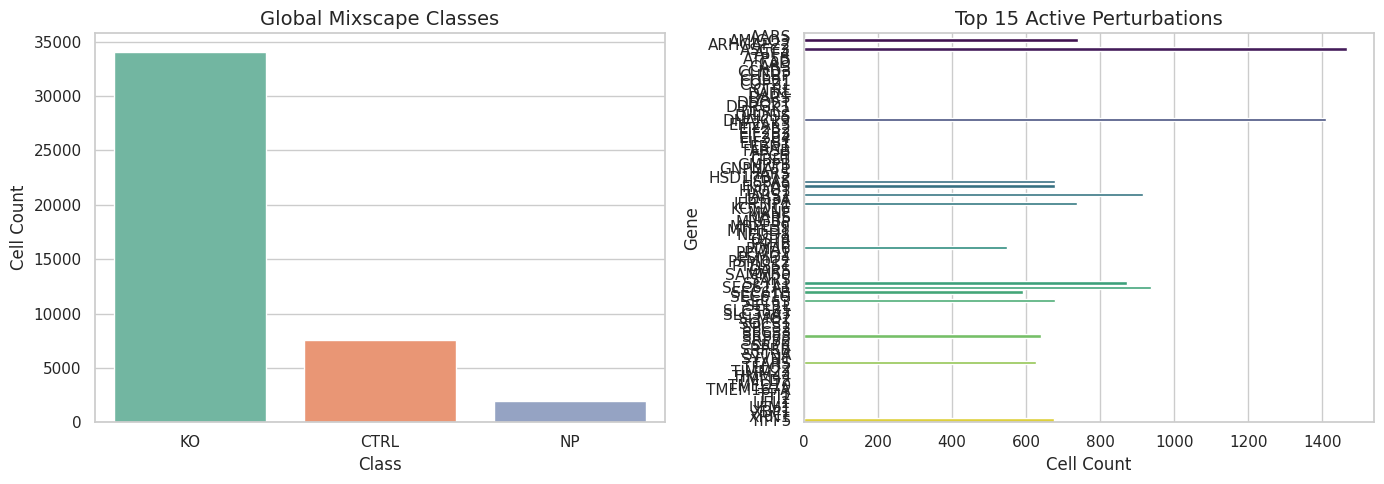

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=adata.obs,
    x='mixscape_class_global',
    ax=axes[0],
    palette='Set2',
    order=['KO', 'CTRL', 'NP']
)
axes[0].set_title('Global Mixscape Classes', fontsize=14)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Cell Count', fontsize=12)

top_pert = adata.obs[adata.obs['gene'] != 'CTRL']['gene'].value_counts().head(15)

sns.barplot(
    x=top_pert.values,
    y=top_pert.index,
    ax=axes[1],
    palette='viridis'
)
axes[1].set_title('Top 15 Active Perturbations', fontsize=14)
axes[1].set_xlabel('Cell Count', fontsize=12)
axes[1].set_ylabel('Gene', fontsize=12)

plt.tight_layout()
plt.show()

In [50]:
print("Top 15 perturbation genes")
print(top_pert.index.tolist())

Top 15 perturbation genes
['ASCC3', 'DNAJC19', 'SEC61A1', 'IARS2', 'SCYL1', 'AMIGO3', 'IER3IP1', 'SEC63', 'HSPA5', 'HSPA9', 'YIPF5', 'SRP68', 'TARS', 'SEC61B', 'PDIA6']


In [12]:
adata.var.head()

,ENSEMBL,ENTREZID,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm
Gene_symbol,,,,,,,,,,,,
MIR1302-10,ENSG00000288468,100422834.0,11,False,11,0.000169,99.983115,11.0,True,0.000132,0.094932,1.195838
SAMD11,ENSG00000187634,148398.0,362,False,362,0.005895,99.444317,384.0,True,0.004291,0.186517,1.581380
HES4,ENSG00000188290,57801.0,32091,False,32091,0.892593,50.739120,58148.0,True,0.431529,0.042266,0.929874
TNFRSF18,ENSG00000186891,8784.0,145,False,145,0.002257,99.777420,147.0,True,0.001794,0.020822,0.883862
TNFRSF4,ENSG00000186827,7293.0,271,False,271,0.005265,99.584005,343.0,True,0.003989,0.427801,2.597102


## Cell-Level Metadata (`obs`)

A few columns stand out immediately:

- `gene`: likely the assigned perturbation target
- `pertclass`: a coarse perturbation class
- `mixscape_class` and `mixscape_class_global`: Mixscape-derived labels
- `leiden`: cluster label
- `n_genes_by_counts`, `total_counts`, `pct_counts_mt`: quality-control covariates

These are especially relevant for our planned treatment/covariate setup.

In [13]:
adata.obs.dtypes.sort_index()

,0
gene,category
leiden,category
mixscape_class,category
mixscape_class_global,category
mixscape_class_p_ko,float64
n_genes,int64
n_genes_by_counts,int32
pct_counts_mt,float32
pertclass,category
total_counts,float32


In [14]:
categorical_cols = [
    col for col in adata.obs.columns
    if str(adata.obs[col].dtype) == 'category'
]

pd.DataFrame({
    'column': categorical_cols,
    'n_categories': [adata.obs[col].cat.categories.size for col in categorical_cols]
}).sort_values('n_categories', ascending=False)


,column,n_categories
2,mixscape_class,89
0,gene,88
1,leiden,13
3,mixscape_class_global,3
4,pertclass,3


In [15]:
adata.obs['gene'].value_counts().head(20)

,count
gene,
CTRL,7546
ASCC3,1467
DNAJC19,1411
SEC61A1,937
IARS2,917
SCYL1,873
AMIGO3,741
IER3IP1,737
SEC63,679


In [16]:
adata.obs['mixscape_class_global'].value_counts(dropna=False)

,count
mixscape_class_global,
KO,34070
CTRL,7546
NP,1934


In [17]:
adata.obs['pertclass'].value_counts(dropna=False)

,count
pertclass,
strong,34012
CTRL,7546
weak,1992


In [18]:
qc_cols = ['n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']
adata.obs[qc_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
n_genes,43550.0,3536.484776,792.879397,962.000000,3032.000000,3585.000000,4087.000000,6548.000000
n_genes_by_counts,43550.0,3536.427830,792.866760,962.000000,3032.000000,3585.000000,4087.000000,6548.000000
total_counts,43550.0,15066.552734,6037.260742,3179.000000,10958.000000,14598.500000,18593.000000,55973.000000
total_counts_mt,43550.0,768.696045,401.532013,1.000000,486.250000,735.000000,995.000000,3909.000000
pct_counts_mt,43550.0,5.039878,1.619069,0.020504,4.095984,5.061648,6.056093,9.992424


## Gene-Level Metadata (`var`)

The variable metadata confirms that the matrix has already been filtered to a set of highly variable genes. That is useful computationally, although it also means this file is not a full raw gene-by-cell matrix.

In [19]:
var_summary = {
    'n_highly_variable': int(adata.var['highly_variable'].sum()),
    'n_mito_genes': int(adata.var['mt'].sum()),
}
var_summary

{'n_highly_variable': 2000, 'n_mito_genes': 4}

In [20]:
gene_stat_cols = ['n_cells', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'means', 'dispersions', 'dispersions_norm']
adata.var[gene_stat_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
n_cells,2000.0,9125.125500,17993.751633,3.000000,9.000000,56.000000,5259.500000,6.514500e+04
n_cells_by_counts,2000.0,9125.125500,17993.751633,3.000000,9.000000,56.000000,5259.500000,6.514500e+04
mean_counts,2000.0,1.146121,7.735916,0.000046,0.000165,0.000959,0.101719,2.178568e+02
pct_dropout_by_counts,2000.0,85.992593,27.621079,0.000000,91.926472,99.914038,99.986185,9.999539e+01
total_counts,2000.0,74664.031250,503956.156250,3.000000,10.750000,62.500000,6626.500000,1.419228e+07
means,2000.0,0.196972,0.519382,0.000024,0.000133,0.000730,0.069364,4.961793e+00
dispersions,2000.0,0.341259,0.513383,-0.011758,0.052647,0.171116,0.393864,4.887420e+00
dispersions_norm,2000.0,2.014368,1.919176,0.746714,0.988638,1.414461,2.218261,2.290254e+01


## Layers, Embeddings, and Graph Structure

The file includes alternate matrices and precomputed embeddings that will be helpful for exploratory analysis.

- `X_pert` and `normal_counts` are extra expression-like matrices
- `X_pca` gives a compact cell-state representation
- `X_umap` gives a 2D visualization
- neighbor graphs in `obsp` can support clustering or local matching ideas later


In [21]:
print('X:', adata.X.shape)
for layer in adata.layers.keys():
    print(f'{layer}:', adata.layers[layer].shape)
for key in adata.obsm.keys():
    print(f'{key}:', adata.obsm[key].shape)


X: (43550, 2000)
X_pert: (43550, 2000)
normal_counts: (43550, 2000)
X_pca: (43550, 50)
X_umap: (43550, 2)


In [22]:
interesting_uns = {
    'hvg': adata.uns.get('hvg', {}),
    'leiden': adata.uns.get('leiden', {}),
    'neighbors': adata.uns.get('neighbors', {}),
    'pca': adata.uns.get('pca', {}),
    'umap': adata.uns.get('umap', {}),
}

for key, value in interesting_uns.items():
    print(f'\n[{key}]')
    print(value)



[hvg]
{'flavor': 'seurat'}

[leiden]
{'params': {'n_iterations': -1, 'random_state': 0, 'resolution': 1}}

[neighbors]
{'connectivities_key': 'connectivities', 'distances_key': 'distances', 'params': {'method': 'umap', 'metric': 'euclidean', 'n_neighbors': 15, 'random_state': 0}}

[pca]
{'params': {'use_highly_variable': True, 'zero_center': True}, 'variance': array([0.9831209 , 0.8560063 , 0.73537946, 0.6034092 , 0.5844645 ,
       0.5318289 , 0.519273  , 0.46532726, 0.43398142, 0.4295015 ,
       0.4120693 , 0.389118  , 0.3816746 , 0.3750041 , 0.36071667,
       0.34780407, 0.3357742 , 0.32450503, 0.3232802 , 0.31976727,
       0.31069383, 0.30251855, 0.29388094, 0.29212618, 0.2878694 ,
       0.28437793, 0.27618715, 0.27499634, 0.27289152, 0.26854578,
       0.26564324, 0.26302886, 0.26220617, 0.25835338, 0.25757015,
       0.25637928, 0.25627205, 0.25467545, 0.25362152, 0.25216123,
       0.25141317, 0.25002283, 0.24912627, 0.2479517 , 0.24662207,
       0.24428639, 0.2428427 , 0.

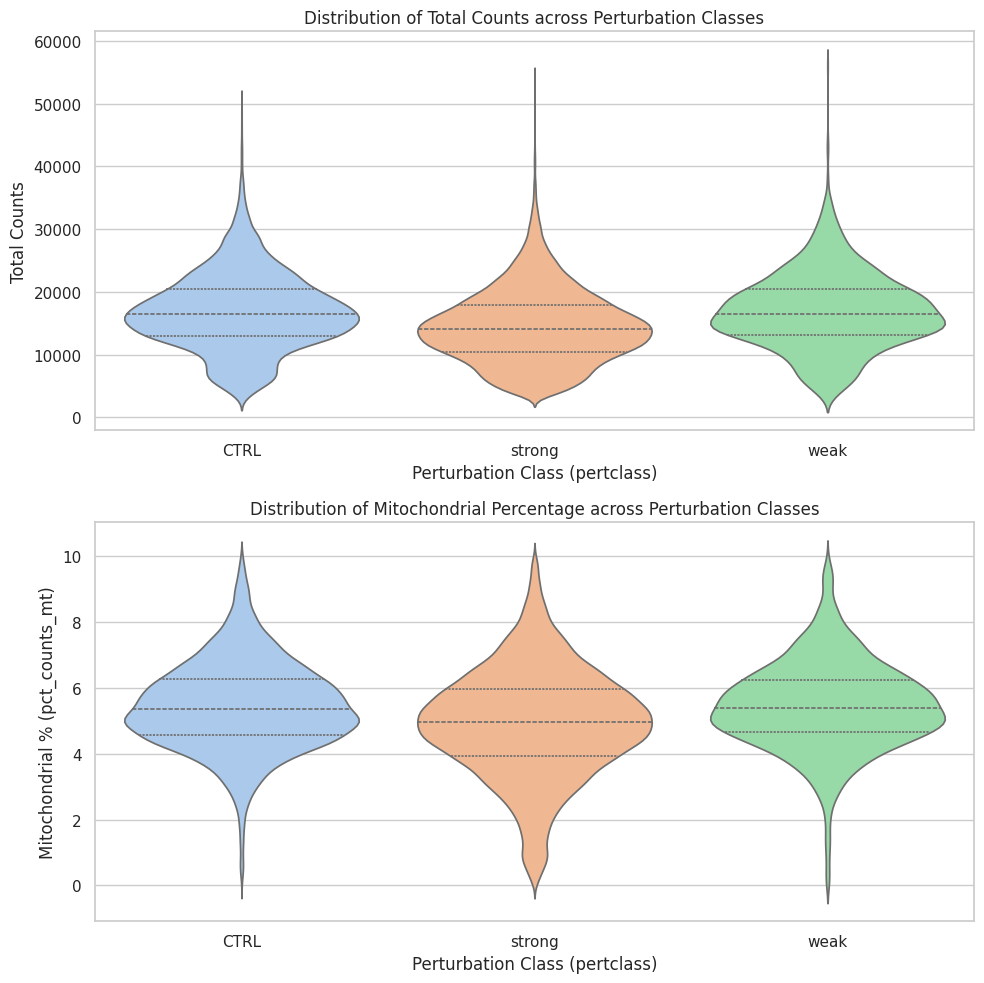

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

sns.violinplot(
    data=adata.obs,
    x='pertclass',
    y='total_counts',
    ax=axes[0],
    palette='pastel',
    inner='quartile'
)
axes[0].set_title('Distribution of Total Counts across Perturbation Classes')
axes[0].set_xlabel('Perturbation Class (pertclass)')
axes[0].set_ylabel('Total Counts')

sns.violinplot(
    data=adata.obs,
    x='pertclass',
    y='pct_counts_mt',
    ax=axes[1],
    palette='pastel',
    inner='quartile'
)
axes[1].set_title('Distribution of Mitochondrial Percentage across Perturbation Classes')
axes[1].set_xlabel('Perturbation Class (pertclass)')
axes[1].set_ylabel('Mitochondrial % (pct_counts_mt)')

plt.tight_layout()
plt.show()

## UMAP Visualization

Since a UMAP embedding is already stored in the file, we can use it to get a fast visual sense of how cells are organized. We will color by a few metadata fields that may matter later.

For teammate readability, the plots below intentionally sample colors and alpha conservatively rather than aiming for publication quality.

In [29]:
plot_df = adata.obs.copy()
plot_df['UMAP1'] = adata.obsm['X_umap'][:, 0]
plot_df['UMAP2'] = adata.obsm['X_umap'][:, 1]
plot_df.head()

,gene,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,mixscape_class_p_ko,mixscape_class,mixscape_class_global,pertclass,UMAP1,UMAP2
Cell_barcodes,,,,,,,,,,,,,
CTCATTGAGAAGGC-6,NEDD8,3820,3820,16201.0,979.0,6.042837,0,0.999475,NEDD8 KO,KO,strong,-4.111902,3.677709
CGGCACGATGACCA-6,DAD1,3853,3853,16371.0,835.0,5.100483,2,0.854574,DAD1 KO,KO,strong,-2.034492,3.769941
AACCTTACTGACCA-7,DNAJC19,1959,1959,5501.0,118.0,2.145065,1,1.000000,DNAJC19 KO,KO,strong,-1.137498,0.107801
GAACGGGAAGTCAC-3,CTRL,3240,3240,14159.0,680.0,4.802599,6,0.000000,CTRL,CTRL,CTRL,-7.006863,3.926451
CAACGAACATCGGT-9,CARS,5012,5012,30639.0,2253.0,7.353373,7,0.907327,CARS KO,KO,strong,-2.687120,2.679804


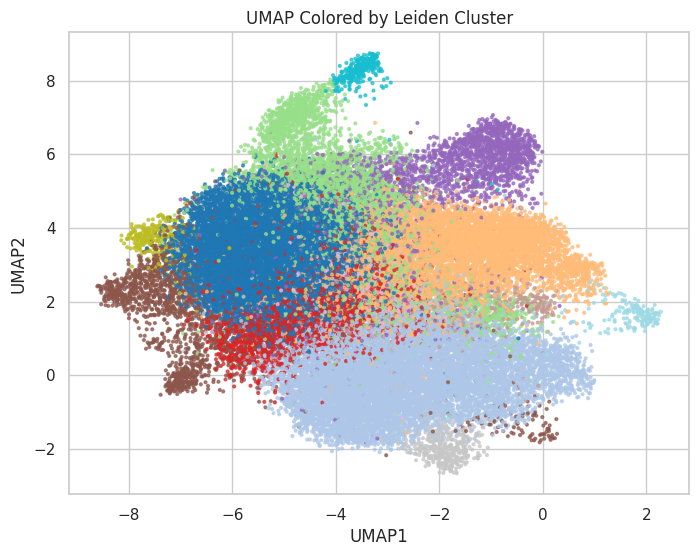

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    plot_df['UMAP1'],
    plot_df['UMAP2'],
    c=plot_df['leiden'].cat.codes,
    s=4,
    alpha=0.7,
    cmap='tab20'
)
ax.set_title('UMAP Colored by Leiden Cluster')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
plt.show()


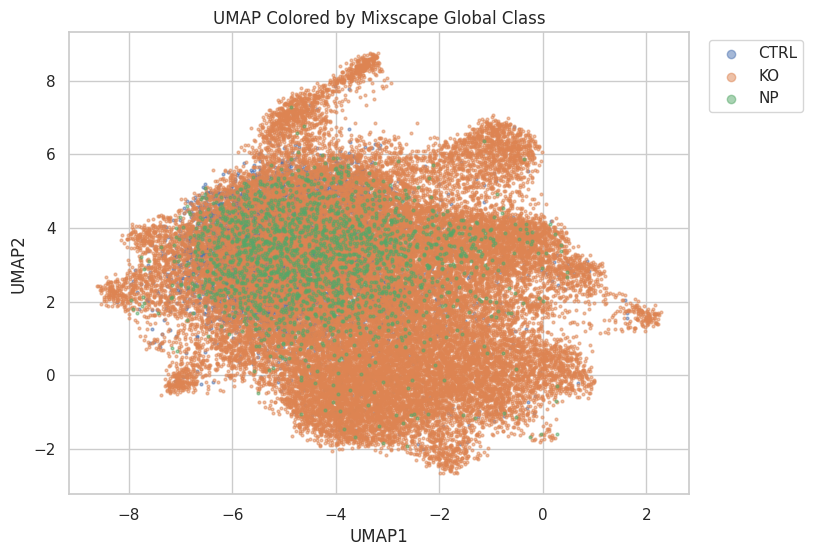

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

for label, group in plot_df.groupby('mixscape_class_global', observed=False):
    ax.scatter(group['UMAP1'], group['UMAP2'], s=4, alpha=0.5, label=str(label))

ax.set_title('UMAP Colored by Mixscape Global Class')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.legend(markerscale=3, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


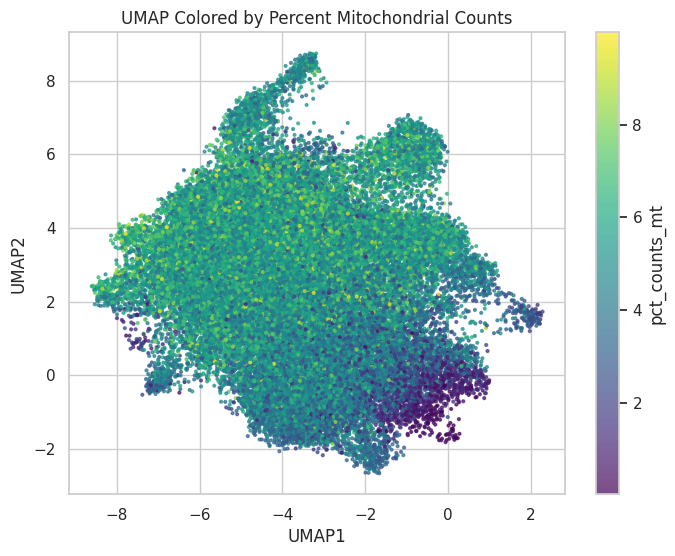

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
points = ax.scatter(
    plot_df['UMAP1'],
    plot_df['UMAP2'],
    c=plot_df['pct_counts_mt'],
    s=4,
    alpha=0.7,
    cmap='viridis'
)
ax.set_title('UMAP Colored by Percent Mitochondrial Counts')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
plt.colorbar(points, ax=ax, label='pct_counts_mt')
plt.show()


Top 3 Highly Variable Genes identified: ['HBE1', 'CCL3', 'IL8']


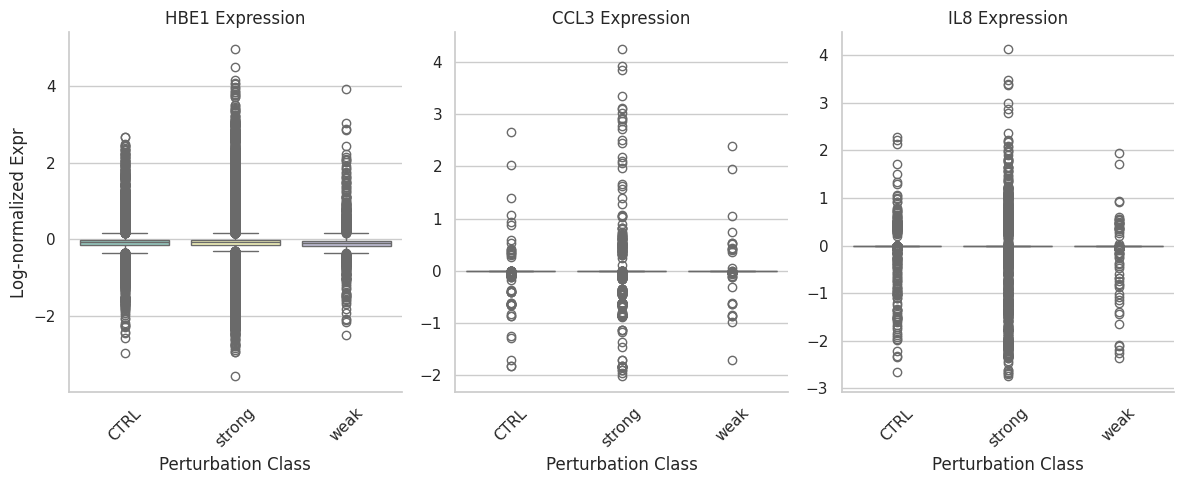

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

top_hvg_genes = adata.var.sort_values(by='dispersions_norm', ascending=False).index[:3].tolist()
print(f"Top 3 Highly Variable Genes identified: {top_hvg_genes}")

plot_data_list = []
for gene in top_hvg_genes:
    if 'data' in adata.layers:
        expr = adata[:, gene].layers['data'].toarray().flatten()
    else:
        expr = adata[:, gene].X.toarray().flatten() if hasattr(adata.X, "toarray") else adata[:, gene].X.flatten()

    tmp_df = pd.DataFrame({
        'Expression': expr,
        'Perturbation_Class': adata.obs['pertclass'],
        'Gene': gene
    })
    plot_data_list.append(tmp_df)

combined_expr_df = pd.concat(plot_data_list, axis=0)

g = sns.FacetGrid(
    combined_expr_df,
    col="Gene",
    sharey=False,
    height=5,
    aspect=0.8,
    palette="Set3"
)

g.map_dataframe(
    sns.boxplot,
    x="Perturbation_Class",
    y="Expression",
    hue="Perturbation_Class",
    dodge=False,
    palette="Set3"
)

g.set_titles(col_template="{col_name} Expression")
g.set_axis_labels("Perturbation Class", "Log-normalized Expr")
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## How This Maps to Our Planned Causal Analysis

At a high level, the dataset seems compatible with our proposed design.

### Candidate treatment variables

- `obs['gene']` appears to encode the perturbation target
- `obs['pertclass']` may provide a coarse class of perturbations
- depending on the project scope, we may subset to one perturbation versus a control-like population

### Candidate covariates

- `obs['n_genes_by_counts']`, `obs['total_counts']`, `obs['pct_counts_mt']`
- `obsm['X_pca']` for cell-state representation
- `obs['leiden']` as a coarse cellular state label

### Candidate outcomes

The current file does not directly contain a pathway score column, but we can define one later from expression values in `X`, `X_pert`, or `normal_counts`, for example:

- a curated gene module average
- a pathway score
- a principal component of selected genes

### Why this preliminary step matters

Before estimating treatment effects, we need to verify:

- which category behaves as the control or baseline condition
- how balanced perturbation groups are in cell-state space
- whether candidate treated cells have comparable controls nearby in PCA space


In [ ]:
for col in ['gene', 'pertclass', 'mixscape_class_global']:
    print(f'\nTop values for {col}:')
    print(adata.obs[col].value_counts().head(15))



Top values for gene:
gene
CTRL       7546
ASCC3      1467
DNAJC19    1411
SEC61A1     937
IARS2       917
SCYL1       873
AMIGO3      741
IER3IP1     737
SEC63       679
HSPA5       678
HSPA9       677
YIPF5       676
SRP68       641
TARS        626
SEC61B      592
Name: count, dtype: int64

Top values for pertclass:
pertclass
strong    34012
CTRL       7546
weak       1992
Name: count, dtype: int64

Top values for mixscape_class_global:
mixscape_class_global
KO      34070
CTRL     7546
NP       1934
Name: count, dtype: int64


## Notes for Teammates

A few practical takeaways from this first pass:

- the dataset is already processed and reduced to `2,000` highly variable genes
- there are built-in embeddings and graph structures, so we do not need to recompute PCA or UMAP just to get started
- perturbation labels appear to be present, but we still need to determine the appropriate control group carefully
- this file alone does not fully document the biological study design, so upstream paper or code context would still be valuable


## Suggested Next Steps

Reasonable follow-up notebooks or scripts would be:

1. Identify control cells and choose one or a few perturbations for the project scope.
2. Define a low-dimensional outcome, such as a pathway score or curated gene module score.
3. Compare naive treated-versus-control differences.
4. Build a state-adjusted estimator using PCA-space matching or kernel weighting.
5. Check overlap and covariate balance before interpreting estimated effects.

That would connect naturally to the project draft without jumping into the full analysis immediately.